## Descrição do Dataset

Dataset sintético do Kaggle (*Diabetes Risk Prediction*) com 15 000 pacientes e 19 colunas. Além do identificador `patient_id` e do alvo `diabetes_risk`, tem 17 features: 6 inteiras, 4 float e 9 categóricas.

O alvo tem três níveis (`Low`, `Moderate` e `High`). O enunciado fala em *medium*, mas no dataset o nível intermédio é `Moderate`.

Importamos as bibs necessárias

In [86]:
from matplotlib.axis import XAxis
import numpy as np
import pandas as pd
import plotly.express as px
from matplotlib.pyplot import scatter, xlabel, ylabel, show
from matplotlib import pyplot as plt

#Vamos criar uma variável para o caminho dos ficheiros, de forma a garantir a replicabilidade do código
DATA_PATH='AC/Projeto/diabetes_risk.csv'

Explorar o dataset, através da sua caracterização

In [87]:
#usar a biblioteca pandas para ler o ficheiro csv
df = pd.read_csv(
    DATA_PATH,
    decimal="."
)
#confirmar que foi carregado corretamente
#df
#visualizamos as primeiras linhas 
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [88]:
#recolher as informações gerais do dataset
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

(15000, 19)

Dividir o dataset pelos diferentes tipos de features

In [89]:
#criar 3 subsections do dataset que contenham as variáveis do tipo inteiro,float e object
features_integers = df.dtypes[df.dtypes == "int64"].index
df_integers = df[features_integers]

features_floats = df.dtypes[df.dtypes == "float64"].index
df_floats = df[features_floats]

features_objects = df.dtypes[df.dtypes == "object"].index
df_objetos = df[features_objects]

#checking
df_integers.info()
df_floats.info()
df_objetos.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   patient_id                15000 non-null  int64
 1   age                       15000 non-null  int64
 2   stress_level              15000 non-null  int64
 3   fasting_blood_sugar       15000 non-null  int64
 4   blood_pressure_systolic   15000 non-null  int64
 5   blood_pressure_diastolic  15000 non-null  int64
dtypes: int64(6)
memory usage: 703.3 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   bmi                     15000 non-null  float64
 1   hours_sleep_per_night   15000 non-null  float64
 2   hba1c_level             15000 non-null  float64
 3   waist_circumference_cm  15000 non-null  float64
dt

Validação posterior (para integer features)

In [90]:
#começar por perceber quais são as features de tipo inteiro e quantas são
number_integer_features=df_integers.shape[1] #se quisesse o numero de linhas teria que usar shape[0]
print("There are " + str(number_integer_features) + " integer features"); #o str converte o valor numa string
print("The features are: ", list(df_integers.columns))

There are 6 integer features
The features are:  ['patient_id', 'age', 'stress_level', 'fasting_blood_sugar', 'blood_pressure_systolic', 'blood_pressure_diastolic']


Análise mais detalhada, por feature

# Feature `Patient ID`

- **Análise puramente teórica:** serve apenas para identificar o paciente em questão.
- **Sem valor estatístico** para prever o risco de diabetes, apesar de ser uma feature inteira.

# Feature `age`

-**Análise estatística através de diferentes passos**

In [91]:
#Passo número 1- Usar a função describe da bib pandas para ver média, mediana, desvio padrão, mínimo, máximo e quartis
df_integers["age"].describe()

count    15000.000000
mean        44.333667
std         10.383753
min         18.000000
25%         38.000000
50%         45.000000
75%         52.000000
max         80.000000
Name: age, dtype: float64

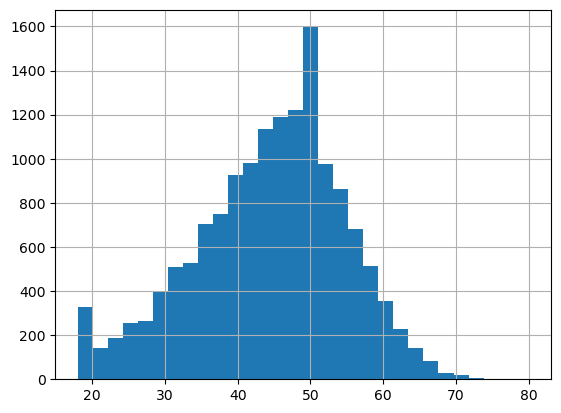

In [92]:
#Passo número 2- Perceber como é que as idades se encontram distribuídas
df_integers["age"].hist(
    bins=30,           # número de barras: o intervalo é dividido em 30 partes iguais
   range=(df_integers["age"].min(),df_integers["age"].max() ) 
)
# Mostra o gráfico
plt.show()

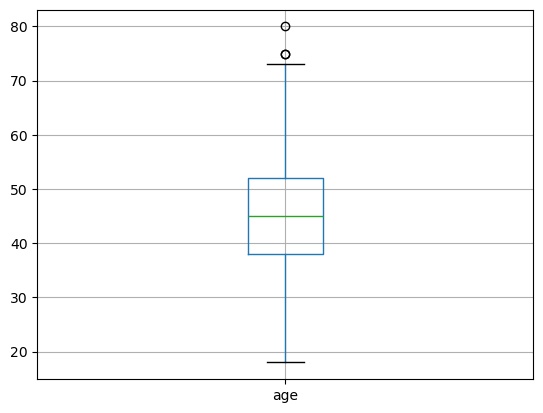

In [93]:
#Passo 3- Continuamos a validação, mas neste caso com boxplot
df_integers.boxplot(column="age")
plt.show()

# Feature `Stress_Level`

-**Análise estatística através de diferentes passos**

count    15000.000000
mean         5.941200
std          2.148406
min          1.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: stress_level, dtype: float64


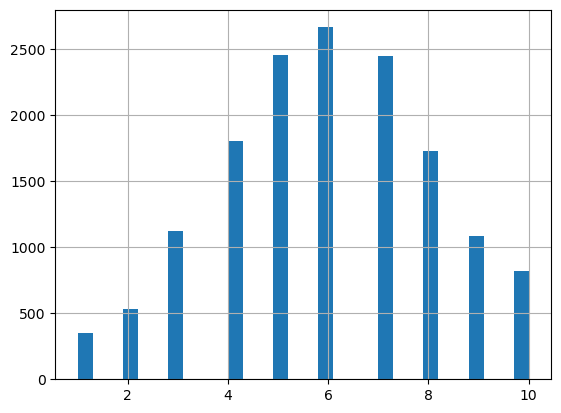

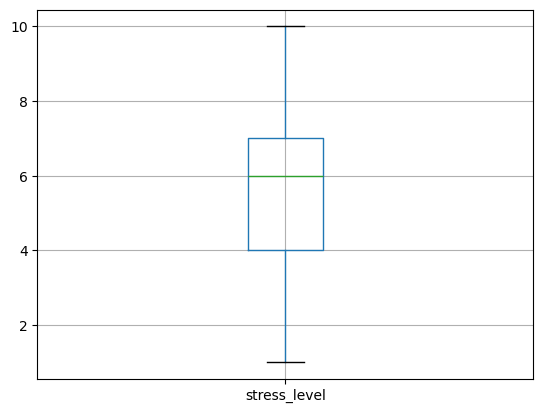

In [94]:
#Por princípios de espaço e de clareza vamos manter o raciocínio usado em "age" mas só num bloco de código 

print(df_integers["stress_level"].describe())
#histograma
df_integers["stress_level"].hist(
    bins=30,           # número de barras: o intervalo é dividido em 30 partes iguais
    range=(df_integers["stress_level"].min(),df_integers["stress_level"].max() ) 
)
# Mostra o gráfico
plt.show()
#boxplot
df_integers.boxplot(column="stress_level")
plt.show()

# Feature `fasting_blood_sugar`

-**Análise estatística através de diferentes passos**

count    15000.000000
mean       168.789933
std         38.365822
min         72.000000
25%        145.000000
50%        165.000000
75%        189.000000
max        400.000000
Name: fasting_blood_sugar, dtype: float64


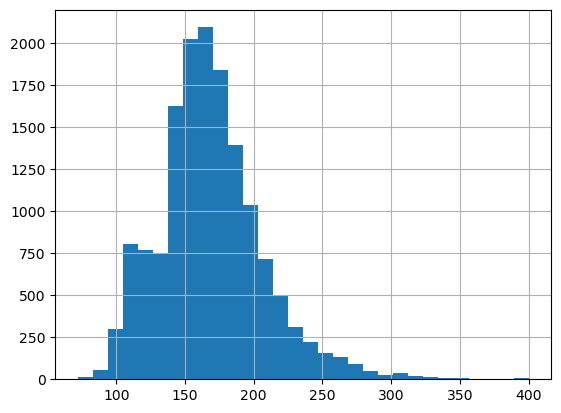

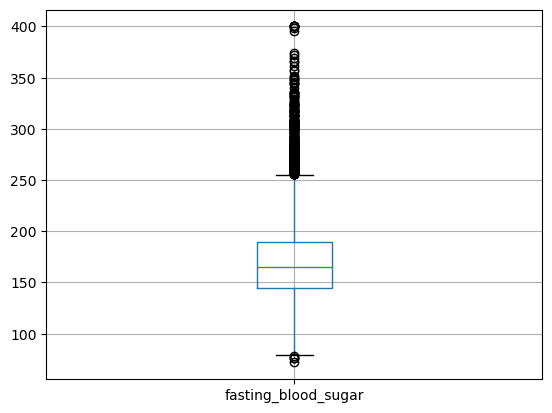

In [95]:
print(df_integers["fasting_blood_sugar"].describe())
#histograma
df_integers["fasting_blood_sugar"].hist(
    bins=30,           # número de barras: o intervalo é dividido em 30 partes iguais
     range=(df_integers["fasting_blood_sugar"].min(),df_integers["fasting_blood_sugar"].max() )    
)
# Mostra o gráfico
plt.show()
#boxplot
df_integers.boxplot(column="fasting_blood_sugar")
plt.show()

# Feature `blood_pressure_systolic`

-**Análise estatística através de diferentes passos**

count    15000.000000
mean       139.496200
std         12.660785
min         80.000000
25%        130.000000
50%        140.000000
75%        150.000000
max        200.000000
Name: blood_pressure_systolic, dtype: float64


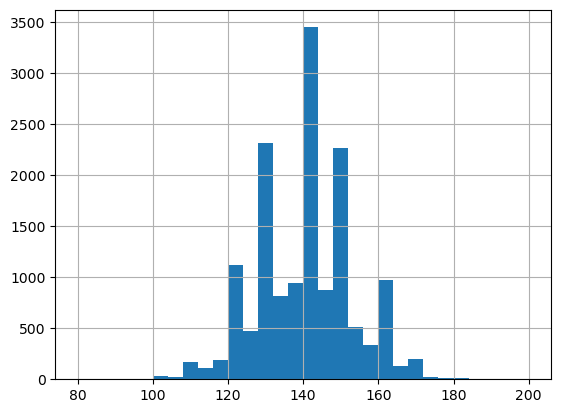

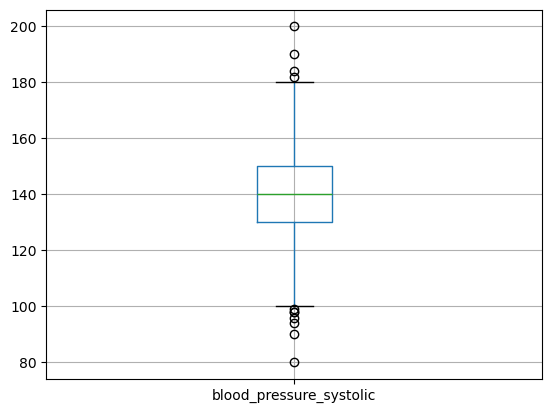

In [96]:
print(df_integers["blood_pressure_systolic"].describe())
#histograma
df_integers["blood_pressure_systolic"].hist(
    bins=30,           # número de barras: o intervalo é dividido em 30 partes iguais
     range=(df_integers["blood_pressure_systolic"].min(),df_integers["blood_pressure_systolic"].max() )      
)
# Mostra o gráfico
plt.show()
#boxplot
df_integers.boxplot(column="blood_pressure_systolic")
plt.show()

# Feature `blood_pressure_diastolic`

-**Análise estatística através de diferentes passos**

count    15000.000000
mean        86.256933
std          8.386529
min         50.000000
25%         80.000000
50%         88.000000
75%         90.000000
max        120.000000
Name: blood_pressure_diastolic, dtype: float64


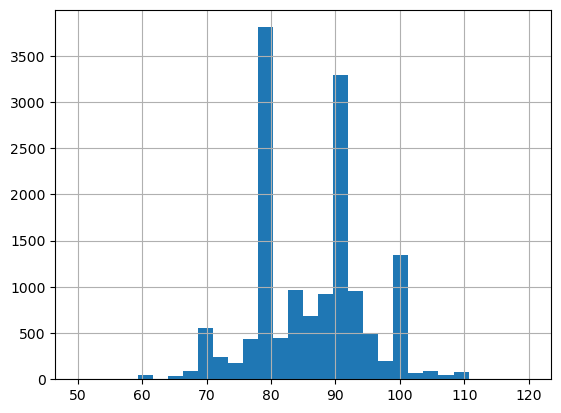

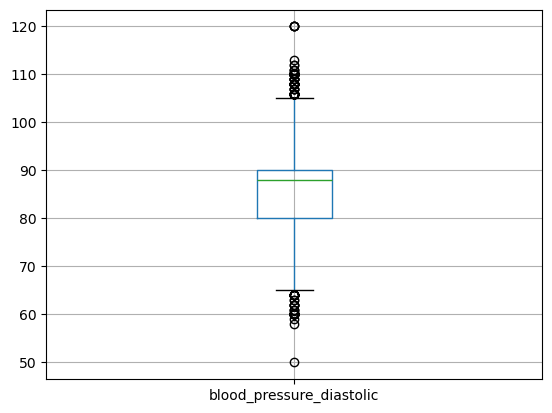

In [97]:
print(df_integers["blood_pressure_diastolic"].describe())
#histograma
df_integers["blood_pressure_diastolic"].hist(
    bins=30,           # número de barras: o intervalo é dividido em 30 partes iguais
    range=(df_integers["blood_pressure_diastolic"].min(),df_integers["blood_pressure_diastolic"].max() )    
)
# Mostra o gráfico
plt.show()
#boxplot
df_integers.boxplot(column="blood_pressure_diastolic")
plt.show()

# Validação posterior para float features

-**Lógica em termos estatísticos é a mesma usada para integer features**

In [98]:
#começar por perceber quais são as features de tipo float e quantas são
number_float_features=df_floats.shape[1] #se quisesse o numero de linhas teria que usar shape[0]
print("There are " + str(number_float_features) + " float features"); #o str converte o valor numa string
print("The features are: ", list(df_floats.columns))

There are 4 float features
The features are:  ['bmi', 'hours_sleep_per_night', 'hba1c_level', 'waist_circumference_cm']


# Feature `bmi`

-**Análise estatística através de diferentes passos**

count    15000.000000
mean        23.062260
std          4.046391
min         15.000000
25%         20.100000
50%         22.700000
75%         25.600000
max         40.800000
Name: bmi, dtype: float64


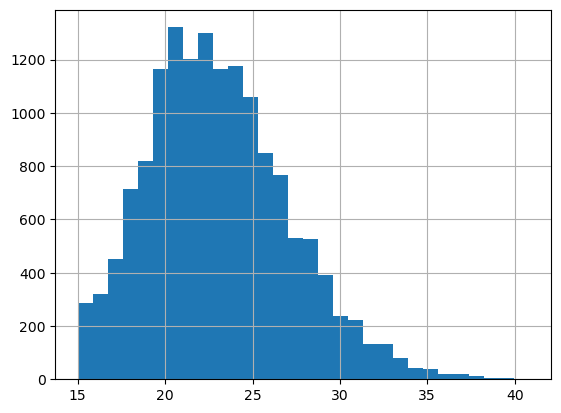

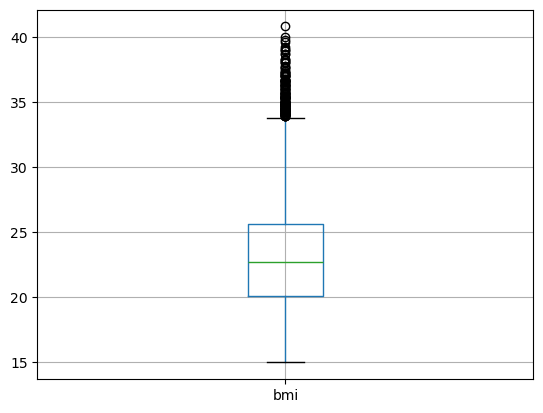

In [99]:
print(df_floats["bmi"].describe())
#histograma
df_floats["bmi"].hist(
    bins=30,           # número de barras: o intervalo é dividido em 30 partes iguais
    range=(df_floats["bmi"].min(),df_floats["bmi"].max() )    
)
# Mostra o gráfico
plt.show()
#boxplot
df_floats.boxplot(column="bmi")
plt.show()

# Feature `hours_sleep_per_night`

-**Análise estatística através de diferentes passos**

count    15000.000000
mean         7.309860
std          1.109372
min          3.000000
25%          6.700000
50%          7.000000
75%          8.000000
max         12.000000
Name: hours_sleep_per_night, dtype: float64


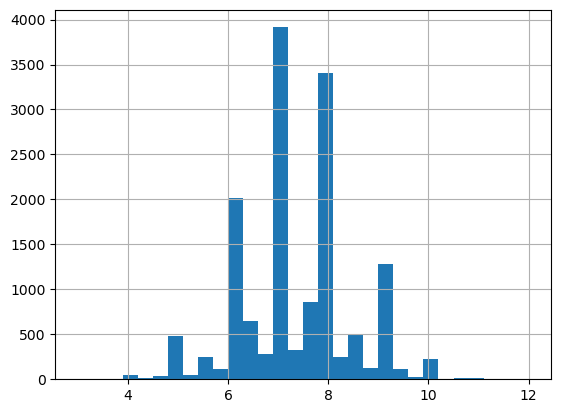

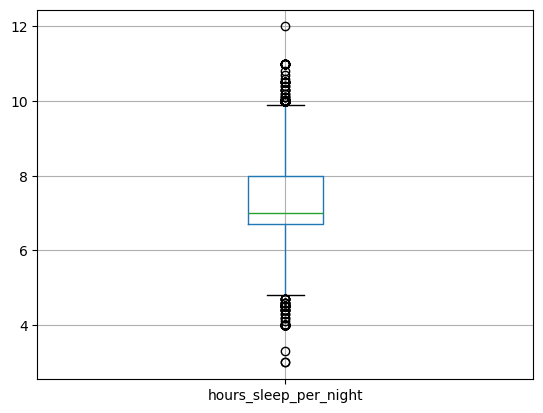

In [100]:
print(df_floats["hours_sleep_per_night"].describe())
#histograma
df_floats["hours_sleep_per_night"].hist(
    bins=30,           # número de barras: o intervalo é dividido em 30 partes iguais
    range=(df_floats["hours_sleep_per_night"].min(),df_floats["hours_sleep_per_night"].max() )    
)
# Mostra o gráfico
plt.show()
#boxplot
df_floats.boxplot(column="hours_sleep_per_night")
plt.show()

# Feature `hba1c_level`

-**Análise estatística através de diferentes passos**

count    15000.000000
mean         6.878387
std          0.843276
min          4.800000
25%          6.300000
50%          6.800000
75%          7.300000
max         13.400000
Name: hba1c_level, dtype: float64


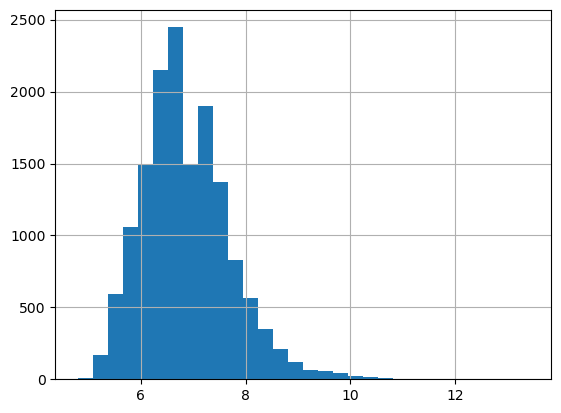

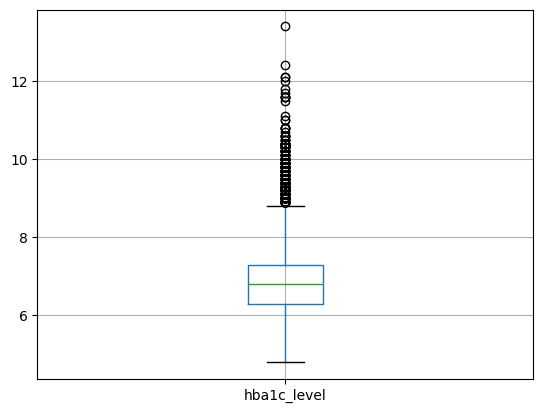

In [101]:
print(df_floats["hba1c_level"].describe())
#histograma
df_floats["hba1c_level"].hist(
    bins=30,           # número de barras: o intervalo é dividido em 30 partes iguais
    range=(df_floats["hba1c_level"].min(),df_floats["hba1c_level"].max() )    
)
# Mostra o gráfico
plt.show()
#boxplot
df_floats.boxplot(column="hba1c_level")
plt.show()

# Feature `waist_circumference_cm`

-**Análise estatística através de diferentes passos**

count    15000.000000
mean       100.207933
std         10.760331
min         73.200000
25%         92.500000
50%         99.300000
75%        106.900000
max        148.200000
Name: waist_circumference_cm, dtype: float64


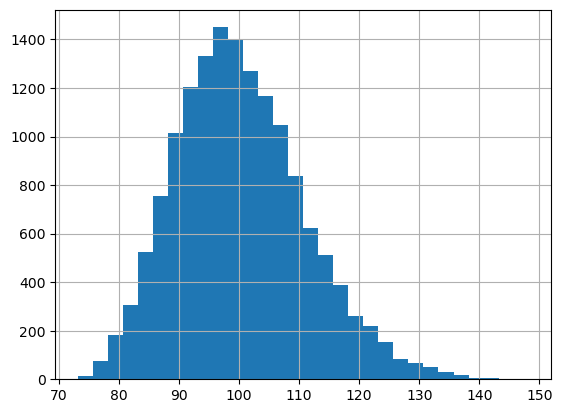

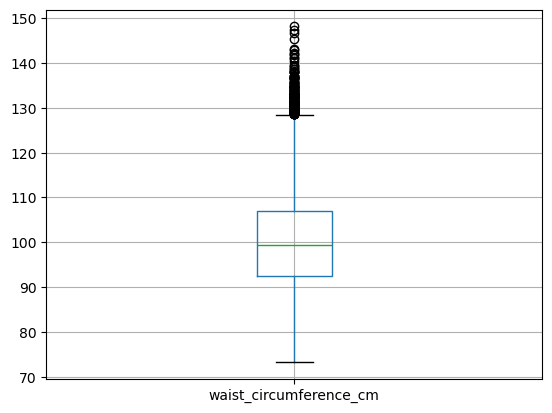

In [102]:
print(df_floats["waist_circumference_cm"].describe())
#histograma
df_floats["waist_circumference_cm"].hist(
    bins=30,           # número de barras: o intervalo é dividido em 30 partes iguais
    range=(df_floats["waist_circumference_cm"].min(),df_floats["waist_circumference_cm"].max() )    
)
# Mostra o gráfico
plt.show()
#boxplot
df_floats.boxplot(column="waist_circumference_cm")
plt.show()

# Validação posterior para object features

-**Lógica é diferente, objetivos serão:**
-->**Contar quantos valores diferentes há**
-->**Contar quantos valores são nulos, se existirem**

In [103]:
#começar por perceber quais são as features de tipo object e quantas são
number_object_features=df_objetos.shape[1] #se quisesse o numero de linhas teria que usar shape[0]
print("There are " + str(number_object_features) + " object features"); #o str converte o valor numa string
print("The features are: ", list(df_objetos.columns))

There are 9 object features
The features are:  ['gender', 'city', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket', 'diabetes_risk']


# Feature `gender`

In [104]:
#Queremos por começar por identificar quantos valores diferentes existem
#começamos por criar um array de strings com as opções diferentes, inicializar a contagem de nulos a 0 e queremos um dicionário que guarde o número de contagens de cada opção
nules_gender=0;
gender_options=[];
gender_options_count={};

#importa salientar que a biblioteca pandas tem uma função .isnull que literalmente confirma a existencia ou não de um valor num csv
for i in df_objetos["gender"]:
    if pd.isnull(i):
        nules_gender=nules_gender+1;
    #quero que se já exisitir aumente a contagem daquele valor
    #se não existir que acrescente o valor à lista e inicie a contagem(1)
    else:
        if i in gender_options:
             gender_options_count[i] = gender_options_count[i] + 1
        else:
            gender_options.append(i)
            gender_options_count[i] = 1

#quantas células estão vazias?
print("A variável gender tem " + str(nules_gender) + " células nulas")
#quantas contagens tem cada elemento?
for categorie_gender in gender_options_count:
   print("Valor:", categorie_gender, "| Contagem:", gender_options_count[categorie_gender])


A variável gender tem 0 células nulas
Valor: Female | Contagem: 7183
Valor: Male | Contagem: 7664
Valor: Other | Contagem: 153


# Feature `city`

In [105]:
#Queremos por começar por identificar quantos valores diferentes existem
#começamos por criar um array de strings com as opções diferentes, inicializar a contagem de nulos a 0 e queremos um dicionário que guarde o número de contagens de cada opção
nules_city=0;
city_options=[];
city_options_count={};

#importa salientar que a biblioteca pandas tem uma função .isnull que literalmente confirma a existencia ou não de um valor num csv
for i in df_objetos["city"]:
    if pd.isnull(i):
        nules_city=nules_city+1;
    #quero que se já exisitir aumente a contagem daquele valor
    #se não existir que acrescente o valor à lista e inicie a contagem(1)
    else:
        if i in city_options:
             city_options_count[i] = city_options_count[i] + 1
        else:
            city_options.append(i)
            city_options_count[i] = 1

#quantas células estão vazias?
print("A variável city tem " + str(nules_city) + " células nulas")
#quantas contagens tem cada elemento?
for categorie_city in city_options_count:
   print("Valor:", categorie_city, "| Contagem:", city_options_count[categorie_city])


A variável city tem 0 células nulas
Valor: Mumbai | Contagem: 2243
Valor: Thane | Contagem: 451
Valor: Bengaluru | Contagem: 1535
Valor: Hyderabad | Contagem: 1227
Valor: Delhi | Contagem: 1737
Valor: Kolkata | Contagem: 872
Valor: Ahmedabad | Contagem: 1039
Valor: Pune | Contagem: 756
Valor: Chennai | Contagem: 933
Valor: Kanpur | Contagem: 475
Valor: Bhopal | Contagem: 399
Valor: Visakhapatnam | Contagem: 307
Valor: Patna | Contagem: 288
Valor: Jaipur | Contagem: 627
Valor: Surat | Contagem: 734
Valor: Nagpur | Contagem: 462
Valor: Indore | Contagem: 458
Valor: Lucknow | Contagem: 457


# Feature `family_history_diabetes`

In [106]:
#Queremos por começar por identificar quantos valores diferentes existem
#começamos por criar um array de strings com as opções diferentes, inicializar a contagem de nulos a 0 e queremos um dicionário que guarde o número de contagens de cada opção
nules_family_history_diabetes=0;
family_history_diabetes_options=[];
family_history_diabetes_options_count={};

#importa salientar que a biblioteca pandas tem uma função .isnull que literalmente confirma a existencia ou não de um valor num csv
for i in df_objetos["family_history_diabetes"]:
    if pd.isnull(i):
        nules_family_history_diabetes=nules_family_history_diabetes+1;
    #quero que se já exisitir aumente a contagem daquele valor
    #se não existir que acrescente o valor à lista e inicie a contagem(1)
    else:
        if i in family_history_diabetes_options:
             family_history_diabetes_options_count[i] = family_history_diabetes_options_count[i] + 1
        else:
            family_history_diabetes_options.append(i)
            family_history_diabetes_options_count[i] = 1

#quantas células estão vazias?
print("A variável family_history_diabetes tem " + str(nules_family_history_diabetes) + " células nulas")
#quantas contagens tem cada elemento?
for categorie_family_history_diabetes in family_history_diabetes_options_count:
   print("Valor:", categorie_family_history_diabetes, "| Contagem:", family_history_diabetes_options_count[categorie_family_history_diabetes])

A variável family_history_diabetes tem 0 células nulas
Valor: Yes | Contagem: 5244
Valor: No | Contagem: 9756


# Feature `physical_activity_level`

In [107]:
#Queremos por começar por identificar quantos valores diferentes existem
#começamos por criar um array de strings com as opções diferentes, inicializar a contagem de nulos a 0 e queremos um dicionário que guarde o número de contagens de cada opção
nules_physical_activity_level=0;
physical_activity_level_options=[];
physical_activity_level_options_count={};

#importa salientar que a biblioteca pandas tem uma função .isnull que literalmente confirma a existencia ou não de um valor num csv
for i in df_objetos["physical_activity_level"]:
    if pd.isnull(i):
        nules_physical_activity_level=nules_physical_activity_level+1;
    #quero que se já exisitir aumente a contagem daquele valor
    #se não existir que acrescente o valor à lista e inicie a contagem(1)
    else:
        if i in physical_activity_level_options:
             physical_activity_level_options_count[i] = physical_activity_level_options_count[i] + 1
        else:
            physical_activity_level_options.append(i)
            physical_activity_level_options_count[i] = 1

#quantas células estão vazias?
print("A variável physical_activity_level tem " + str(nules_physical_activity_level) + " células nulas")
#quantas contagens tem cada elemento?
for categorie_physical_activity_level in physical_activity_level_options_count:
   print("Valor:", categorie_physical_activity_level, "| Contagem:", physical_activity_level_options_count[categorie_physical_activity_level])

A variável physical_activity_level tem 0 células nulas
Valor: Sedentary | Contagem: 4950
Valor: Moderate | Contagem: 4950
Valor: Active | Contagem: 5100


# Feature `diet_type`

In [108]:
#Queremos por começar por identificar quantos valores diferentes existem
#começamos por criar um array de strings com as opções diferentes, inicializar a contagem de nulos a 0 e queremos um dicionário que guarde o número de contagens de cada opção
nules_diet_type=0;
diet_type_options=[];
diet_type_options_count={};

#importa salientar que a biblioteca pandas tem uma função .isnull que literalmente confirma a existencia ou não de um valor num csv
for i in df_objetos["diet_type"]:
    if pd.isnull(i):
        nules_diet_type=nules_diet_type+1;
    #quero que se já exisitir aumente a contagem daquele valor
    #se não existir que acrescente o valor à lista e inicie a contagem(1)
    else:
        if i in diet_type_options:
             diet_type_options_count[i] = diet_type_options_count[i] + 1
        else:
            diet_type_options.append(i)
            diet_type_options_count[i] = 1

#quantas células estão vazias?
print("A variável diet_type tem " + str(nules_diet_type) + " células nulas")
#quantas contagens tem cada elemento?
for categorie_diet_type in diet_type_options_count:
   print("Valor:", categorie_diet_type, "| Contagem:", diet_type_options_count[categorie_diet_type])

A variável diet_type tem 0 células nulas
Valor: Vegetarian | Contagem: 6074
Valor: Non-Vegetarian | Contagem: 8195
Valor: Pescatarian | Contagem: 445
Valor: Vegan | Contagem: 286


# Feature `smoking_status`

In [109]:
#Queremos por começar por identificar quantos valores diferentes existem
#começamos por criar um array de strings com as opções diferentes, inicializar a contagem de nulos a 0 e queremos um dicionário que guarde o número de contagens de cada opção
nules_smoking_status=0;
smoking_status_options=[];
smoking_status_options_count={};

#importa salientar que a biblioteca pandas tem uma função .isnull que literalmente confirma a existencia ou não de um valor num csv
for i in df_objetos["smoking_status"]:
    if pd.isnull(i):
        nules_smoking_status=nules_smoking_status+1;
    #quero que se já exisitir aumente a contagem daquele valor
    #se não existir que acrescente o valor à lista e inicie a contagem(1)
    else:
        if i in smoking_status_options:
             smoking_status_options_count[i] = smoking_status_options_count[i] + 1
        else:
            smoking_status_options.append(i)
            smoking_status_options_count[i] = 1

#quantas células estão vazias?
print("A variável smoking_status tem " + str(nules_smoking_status) + " células nulas")
#quantas contagens tem cada elemento?
for categorie_smoking_status in smoking_status_options_count:
   print("Valor:", categorie_smoking_status, "| Contagem:", smoking_status_options_count[categorie_smoking_status])

A variável smoking_status tem 472 células nulas
Valor: Never | Contagem: 10119
Valor: Current | Contagem: 2946
Valor: Former | Contagem: 1463


# Feature `alcohol_consumption`

In [110]:
#Queremos por começar por identificar quantos valores diferentes existem
#começamos por criar um array de strings com as opções diferentes, inicializar a contagem de nulos a 0 e queremos um dicionário que guarde o número de contagens de cada opção
nules_alcohol_consumption=0;
alcohol_consumption_options=[];
alcohol_consumption_options_count={};

#importa salientar que a biblioteca pandas tem uma função .isnull que literalmente confirma a existencia ou não de um valor num csv
for i in df_objetos["alcohol_consumption"]:
    if pd.isnull(i):
        nules_alcohol_consumption=nules_alcohol_consumption+1;
    #quero que se já exisitir aumente a contagem daquele valor
    #se não existir que acrescente o valor à lista e inicie a contagem(1)
    else:
        if i in alcohol_consumption_options:
             alcohol_consumption_options_count[i] = alcohol_consumption_options_count[i] + 1
        else:
            alcohol_consumption_options.append(i)
            alcohol_consumption_options_count[i] = 1

#quantas células estão vazias?
print("A variável alcohol_consumption tem " + str(nules_alcohol_consumption) + " células nulas")
#quantas contagens tem cada elemento?
for categorie_alcohol_consumption in alcohol_consumption_options_count:
   print("Valor:", categorie_alcohol_consumption, "| Contagem:", alcohol_consumption_options_count[categorie_alcohol_consumption])

A variável alcohol_consumption tem 3788 células nulas
Valor: Never | Contagem: 5616
Valor: Regular | Contagem: 1113
Valor: Occasional | Contagem: 4483


# Feature `income_bracket`

In [111]:
#Queremos por começar por identificar quantos valores diferentes existem
#começamos por criar um array de strings com as opções diferentes, inicializar a contagem de nulos a 0 e queremos um dicionário que guarde o número de contagens de cada opção
nules_income_bracket=0;
income_bracket_options=[];
income_bracket_options_count={};

#importa salientar que a biblioteca pandas tem uma função .isnull que literalmente confirma a existencia ou não de um valor num csv
for i in df_objetos["income_bracket"]:
    if pd.isnull(i):
        nules_income_bracket=nules_income_bracket+1;
    #quero que se já exisitir aumente a contagem daquele valor
    #se não existir que acrescente o valor à lista e inicie a contagem(1)
    else:
        if i in income_bracket_options:
             income_bracket_options_count[i] = income_bracket_options_count[i] + 1
        else:
            income_bracket_options.append(i)
            income_bracket_options_count[i] = 1

#quantas células estão vazias?
print("A variável income_bracket tem " + str(nules_income_bracket) + " células nulas")
#quantas contagens tem cada elemento?
for categorie_income_bracket in income_bracket_options_count:
   print("Valor:", categorie_income_bracket, "| Contagem:", income_bracket_options_count[categorie_income_bracket])

A variável income_bracket tem 463 células nulas
Valor: High | Contagem: 3844
Valor: Low | Contagem: 3388
Valor: Middle | Contagem: 7305


# Feature alvo `diabetes_risk`

In [112]:
#Queremos por começar por identificar quantos valores diferentes existem
#começamos por criar um array de strings com as opções diferentes, inicializar a contagem de nulos a 0 e queremos um dicionário que guarde o número de contagens de cada opção
nules_diabetes_risk=0;
diabetes_risk_options=[];
diabetes_risk_options_count={};

#importa salientar que a biblioteca pandas tem uma função .isnull que literalmente confirma a existencia ou não de um valor num csv
for i in df_objetos["diabetes_risk"]:
    if pd.isnull(i):
        nules_diabetes_risk=nules_diabetes_risk+1;
    #quero que se já exisitir aumente a contagem daquele valor
    #se não existir que acrescente o valor à lista e inicie a contagem(1)
    else:
        if i in diabetes_risk_options:
             diabetes_risk_options_count[i] = diabetes_risk_options_count[i] + 1
        else:
            diabetes_risk_options.append(i)
            diabetes_risk_options_count[i] = 1

#quantas células estão vazias?
print("A variável diabetes_risk tem " + str(nules_diabetes_risk) + " células nulas (" + str(round(nules_diabetes_risk / len(df_objetos) * 100, 2)) + "%)")
#quantas contagens tem cada elemento?
for categorie_diabetes_risk in diabetes_risk_options_count:
   #adicionamos as percentagens para termos noção das distribuições
   print("Valor:", categorie_diabetes_risk, "| Contagem:", diabetes_risk_options_count[categorie_diabetes_risk], "| Percentagem:", str(round(diabetes_risk_options_count[categorie_diabetes_risk] / len(df_objetos) * 100, 2)) + "%")

A variável diabetes_risk tem 0 células nulas (0.0%)
Valor: Low | Contagem: 9000 | Percentagem: 60.0%
Valor: High | Contagem: 2250 | Percentagem: 15.0%
Valor: Moderate | Contagem: 3750 | Percentagem: 25.0%


## Relações das features com o alvo

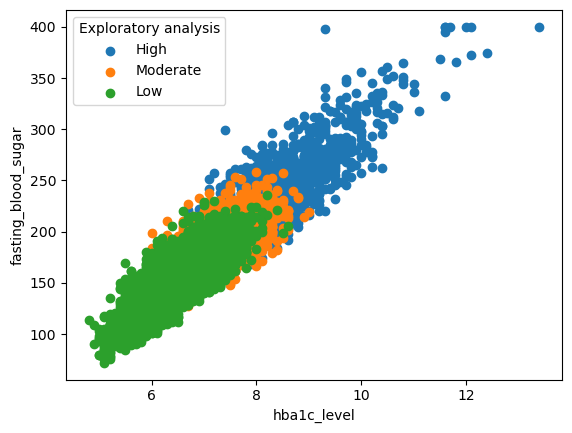

In [115]:
#Clinicamente sabemos que hba1c_level e fasting_blood_sugar têm tendência a ser boas features preditivas de diabetes
#Por mera curiosidade dos autores do presente trabalho, decidimos fazer um scatter plot, meramente exploratório, com essas mesmas features, indo ao encontro do lecionado na primeira aula da disciplina de AC
#Nota: o código usado nesta secção foi desenvolvido pelos autores na Aula 1 e reutilizado no âmbito deste trabalho

plt.scatter(df[df["diabetes_risk"] == "High"]["hba1c_level"], df[df["diabetes_risk"] == "High"]["fasting_blood_sugar"], label="High") #vai buscar todas as da classe High
plt.scatter(df[df["diabetes_risk"] == "Moderate"]["hba1c_level"], df[df["diabetes_risk"] == "Moderate"]["fasting_blood_sugar"], label="Moderate") #vai buscar todas as da classe Moderate
plt.scatter(df[df["diabetes_risk"] == "Low"]["hba1c_level"], df[df["diabetes_risk"] == "Low"]["fasting_blood_sugar"], label="Low") #vai buscar todas as da classe Low

plt.xlabel("hba1c_level")
plt.ylabel("fasting_blood_sugar")
plt.legend(title="Exploratory analysis")
plt.show()


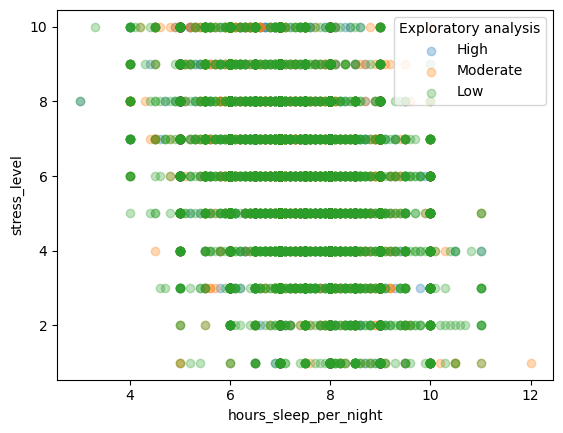

In [116]:
#Como contraste, usamos duas features que acreditamos terem menos ligação à diabetes (horas de sono e stress)
#A ideia não é ver se estão relacionadas entre si, mas se conseguem separar os grupos de risco
#Se a nuvem estiver misturada, o par não ajuda a prever o risco, e fica assim comparável ao primeiro gráfico

plt.scatter(df[df["diabetes_risk"] == "High"]["hours_sleep_per_night"], df[df["diabetes_risk"] == "High"]["stress_level"], label="High", alpha=0.3) #vai buscar todas as da classe High
plt.scatter(df[df["diabetes_risk"] == "Moderate"]["hours_sleep_per_night"], df[df["diabetes_risk"] == "Moderate"]["stress_level"], label="Moderate", alpha=0.3) #vai buscar todas as da classe Moderate
plt.scatter(df[df["diabetes_risk"] == "Low"]["hours_sleep_per_night"], df[df["diabetes_risk"] == "Low"]["stress_level"], label="Low", alpha=0.3) #vai buscar todas as da classe Low

plt.xlabel("hours_sleep_per_night")
plt.ylabel("stress_level")
plt.legend(title="Exploratory analysis")
plt.show()

## Conclusões

A variável alvo está desequilibrada: 60% `Low`, 25% `Moderate` e 15% `High`. Isto deve ser tido em conta na escolha das métricas.

Três features têm valores em falta: `alcohol_consumption` (cerca de 25%), `smoking_status` (472) e `income_bracket` (463). As restantes estão completas.